In [ ]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [ ]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of {path}:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Streaming output truncated to the last 5000 lines.
                person952_bacteria_2877.jpeg
                person1315_virus_2270.jpeg
                person1392_bacteria_3538.jpeg
                person475_bacteria_2025.jpeg
                person1288_bacteria_3251.jpeg
                person1005_virus_1688.jpeg
                person442_virus_900.jpeg
                person755_bacteria_2659.jpeg
                person655_bacteria_2547.jpeg
                person126_virus_255.jpeg
                person16_bacteria_53.jpeg
                person364_virus_743.jpeg
                person382_bacteria_1745.jpeg
                person898_bacteria_2823.jpeg
                person1145_virus_1906.jpeg
                person1004_bacteria_2935.jpeg
                person1088_virus_1800.jpeg
                person501_bacteria_2112.jpeg
                person1718_bacteria_4540.jpeg
                person775_bacteria_2679.jpeg
                person550_bacteria_2309.jpeg
                person7

In [ ]:
print(path)
print(os.listdir(path))
print(os.listdir(path))
base_dir = os.path.join(path, "chest_xray")
train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")
print(os.listdir(train_dir))


/kaggle/input/chest-xray-pneumonia
['chest_xray']
['chest_xray']
['PNEUMONIA', 'NORMAL']


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 154s 749ms/step - accuracy: 0.6005 - loss: 0.7312 - val_accuracy: 0.8125 - val_loss: 0.4914
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 669ms/step - accuracy: 0.7471 - loss: 0.5139 - val_accuracy: 0.8750 - val_loss: 0.4595
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 654ms/step - accuracy: 0.8121 - loss: 0.4114 - val_accuracy: 0.8125 - val_loss: 0.4485
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 660ms/step - accuracy: 0.8541 - loss: 0.3418 - val_accuracy: 0.8125 - val_loss: 0.4390
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 656ms/step - accuracy: 0.8758 - loss: 0.2988 - val_accuracy: 0.8125 - val_loss: 0.4358
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 668ms/step - accuracy: 0.8909 - loss: 0.2726 - val_accuracy: 0.8125 - val_loss: 0.4328
Epoch 7/20

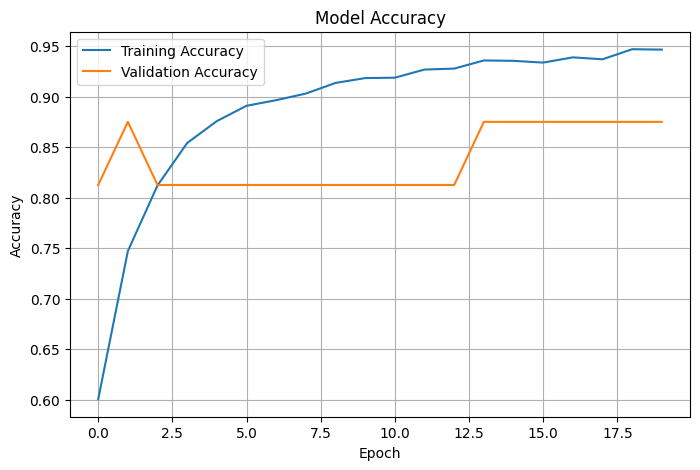

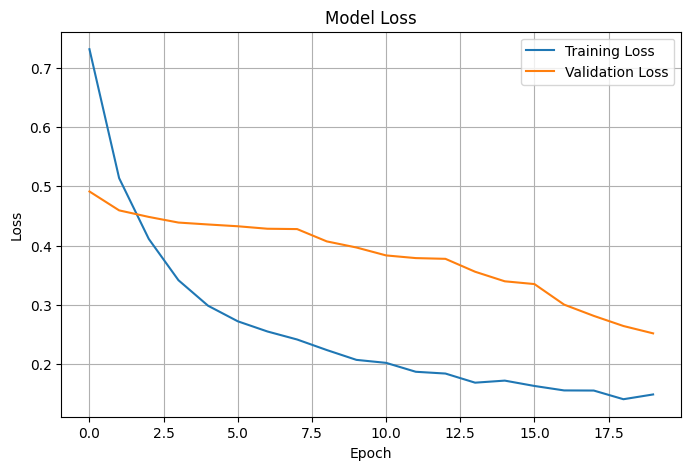

20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 924ms/step

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.77      0.84       234
           1       0.87      0.97      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.87      0.88       624
weighted avg       0.90      0.89      0.89       624


Confusion Matrix

[[180  54]
 [ 13 377]]


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
from tensorflow.keras.callbacks import ReduceLROnPlateau

base_dir = os.path.join(path, "chest_xray")

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation and test data generator
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

# Load validation data
val_data = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

# Load test data
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Load the pre-trained DenseNet121 model
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Build the classification model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stop, checkpoint, reduce_lr]

# Train the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

model.save("../models/pneumonia_model.keras")

# Evaluate the model
loss, accuracy = model.evaluate(test_data)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# ==============================
# Accuracy Graph
# ==============================

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ==============================
# Loss Graph
# ==============================

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ==============================
# Predictions
# ==============================

predictions = model.predict(test_data)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_data.classes

# ==============================
# Classification Report
# ==============================

print("\nClassification Report\n")
print(classification_report(true_classes, predicted_classes))

# ==============================
# Confusion Matrix
# ==============================

print("\nConfusion Matrix\n")
print(confusion_matrix(true_classes, predicted_classes))